<a href="https://colab.research.google.com/github/Wasayyyyyy/CV-Tasks/blob/main/LAB_05_HOG_Defect_Detection_Steel_043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05: HOG-Based Industrial Defect Detection and Classification
**Pipeline:** Image → Preprocessing (resize, grayscale, CLAHE) → HOG → ML classifier (SVM / RF / kNN) → Accept / Reject

Run all cells top to bottom (Runtime → Run all). A GPU is **not** needed. Every result is printed in a bordered block, and tables are saved to `results/`.

**Note on the dataset:** NEU-DET contains 6 defect classes and *no defect-free images*. This notebook therefore runs
1. a **6-class defect classification** (the lab's advanced task), and
2. a **binary Defective / Non-Defective** task, where the classes listed in `PROXY_NORMAL` (config cell) are treated as the "acceptable" class.
If you have real defect-free images, see the note in the config cell.

## 1. Setup

In [1]:
!pip -q install scikit-image

In [2]:
import os, re, glob, time, random, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from skimage.feature import hog
from joblib import Parallel, delayed
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

# ---------------- CONFIG ----------------
SEED = 42
IMG_SIZE = 128
CLASSES = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
# NEU-DET has no 'normal' class. Classes listed here are treated as Class 0 (acceptable / non-defective)
# for the binary task. Change this list (or set [] and add your own normal images) as you wish.
PROXY_NORMAL = ["crazing"]
CELL_SIZES = [4, 8, 16]
ORIENTATIONS = [6, 9, 12]
# ----------------------------------------
random.seed(SEED); np.random.seed(SEED)
os.makedirs("results", exist_ok=True)

def box(title, body, width=78):
    lines = str(body).split("\n")
    w = max(width, max(len(l) for l in lines) + 4, len(title) + 6)
    print("+" + "=" * (w - 2) + "+")
    print("| " + title.center(w - 4) + " |")
    print("+" + "-" * (w - 2) + "+")
    for l in lines:
        print("| " + l.ljust(w - 4) + " |")
    print("+" + "=" * (w - 2) + "+\n")

## 2. Load and inspect the dataset

In [3]:
import os, subprocess, shutil
# NEU-DET images come from a public GitHub mirror: no Kaggle account, API key or manual download needed.
REPO = "https://github.com/siddhartamukherjee/NEU-DET-Steel-Surface-Defect-Detection.git"
DATA_ROOT = "/content/NEU-DET"
if not os.path.isdir(os.path.join(DATA_ROOT, "IMAGES")):
    shutil.rmtree(DATA_ROOT, ignore_errors=True)
    r = subprocess.run(["git", "clone", "--depth", "1", REPO, DATA_ROOT], capture_output=True, text=True)
    print(r.stdout[-300:], r.stderr[-300:])
n_img = sum(f.lower().endswith(".jpg") for _, _, fs in os.walk(DATA_ROOT) for f in fs)
print("Dataset path:", DATA_ROOT, "| JPG images found:", n_img)   # expect ~1800
assert n_img > 1000, "Clone failed - check that Colab has internet access"

 Cloning into '/content/NEU-DET'...
Updating files:  97% (3560/3657)
Updating files:  97% (3564/3657)
Updating files:  98% (3584/3657)
Updating files:  99% (3621/3657)
Updating files: 100% (3657/3657)
Updating files: 100% (3657/3657), done.

Dataset path: /content/NEU-DET | JPG images found: 1802


In [4]:
def norm(s): return re.sub(r"[\s\-]+", "_", s.lower())
NCLS = [norm(c) for c in CLASSES]
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

records = []
for p in glob.glob(os.path.join(DATA_ROOT, "**", "*"), recursive=True):
    if not p.lower().endswith(EXTS): continue
    rel = os.path.relpath(p, DATA_ROOT)
    parts = [norm(x) for x in rel.split(os.sep)]
    cls = next((x for x in reversed(parts[:-1]) if x in NCLS), None)
    if cls is None:  # fall back to filename prefix, e.g. crazing_12.jpg
        cls = next((c for c in NCLS if parts[-1].startswith(c)), None)
    if cls is None: continue
    split = "train" if any(x.startswith("train") for x in parts[:-1]) else \
            "test" if any(x.startswith(("val", "test")) for x in parts[:-1]) else None
    records.append(dict(path=p, cls=CLASSES[NCLS.index(cls)], split=split))
df = pd.DataFrame(records)
assert len(df) > 0, "No images found - check DATA_ROOT"

if df.split.isna().any() or df.split.nunique() < 2:   # no official split found -> stratified 80/20
    from sklearn.model_selection import train_test_split
    tr, te = train_test_split(df.index, test_size=0.2, stratify=df.cls, random_state=SEED)
    df["split"] = "train"; df.loc[te, "split"] = "test"

df["cls_id"] = df.cls.map({c: i for i, c in enumerate(CLASSES)})
df["bin"] = (~df.cls.isin(PROXY_NORMAL)).astype(int)   # 1 = defective, 0 = non-defective (proxy)
df.to_csv("results/dataset_index.csv", index=False)

summary = pd.crosstab(df.cls, df.split)
box("DATASET SUMMARY", f"Total images : {len(df)}\nTrain / Test : {(df.split=='train').sum()} / {(df.split=='test').sum()}\n"
    f"Classes      : {len(CLASSES)}\nProxy normal : {PROXY_NORMAL}\n\n" + summary.to_string())

+============================================================================+
|                              DATASET SUMMARY                               |
+----------------------------------------------------------------------------+
| Total images : 1800                                                        |
| Train / Test : 1440 / 360                                                  |
| Classes      : 6                                                           |
| Proxy normal : ['crazing']                                                 |
|                                                                            |
| split            test  train                                               |
| cls                                                                        |
| crazing            60    240                                               |
| inclusion          60    240                                               |
| patches            60    240                      

+============================================================================+
|                                 IMAGE INFO                                 |
+----------------------------------------------------------------------------+
| Original image shape : (200, 200)                                          |
| Pixel range          : 51 - 255                                            |
+============================================================================+



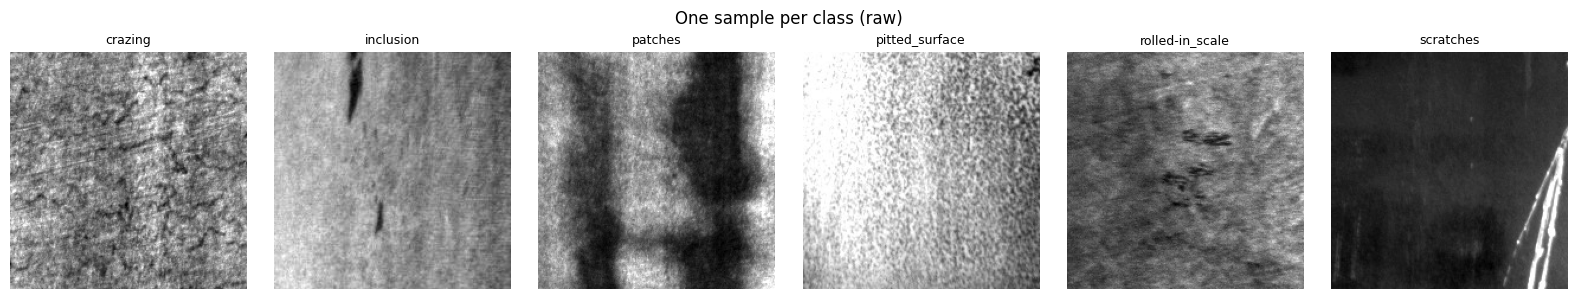

In [5]:
# Load raw grayscale images
def load_gray(paths): return [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in paths]
tr_df = df[df.split == "train"].reset_index(drop=True)
te_df = df[df.split == "test"].reset_index(drop=True)
raw_tr, raw_te = load_gray(tr_df.path), load_gray(te_df.path)
box("IMAGE INFO", f"Original image shape : {raw_tr[0].shape}\nPixel range          : {raw_tr[0].min()} - {raw_tr[0].max()}")

fig, ax = plt.subplots(1, 6, figsize=(16, 3))
for a, c in zip(ax, CLASSES):
    i = tr_df.index[tr_df.cls == c][0]
    a.imshow(raw_tr[i], cmap="gray"); a.set_title(c, fontsize=9); a.axis("off")
plt.suptitle("One sample per class (raw)"); plt.tight_layout(); plt.show()

## 3. Preprocessing (resize → grayscale → CLAHE) and HOG extraction

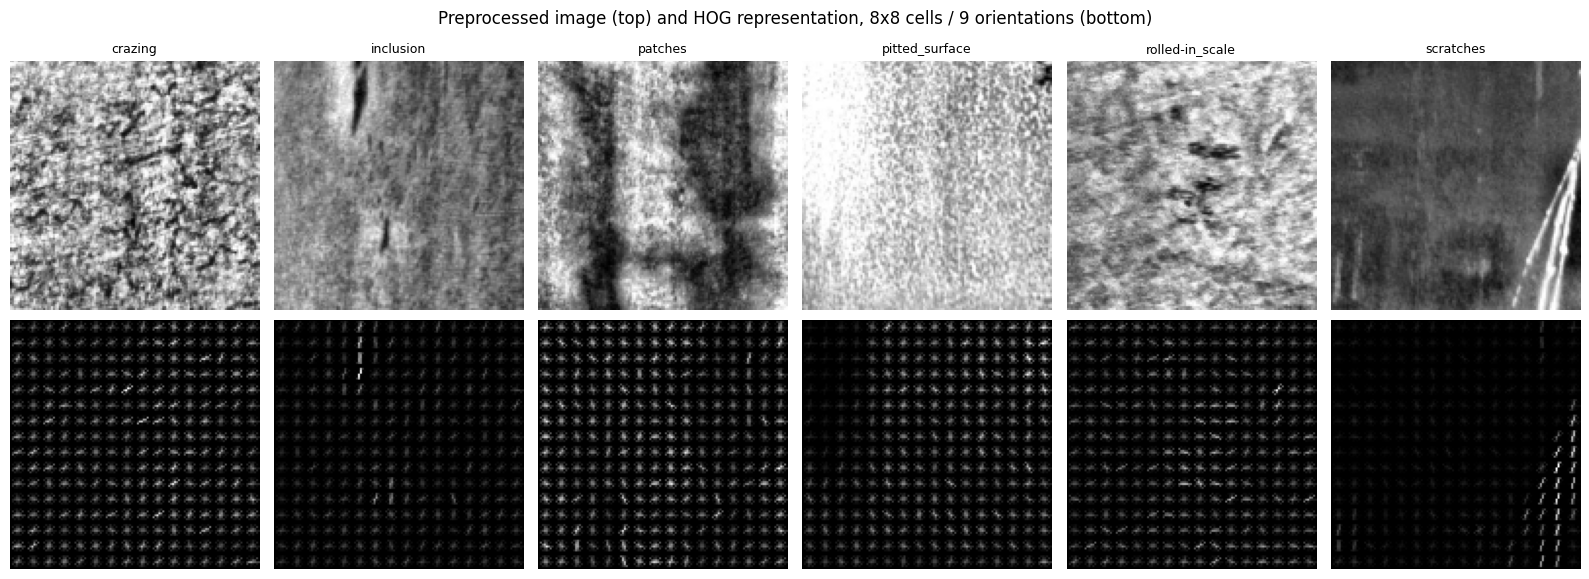

+===============================================================================+
|                           HOG FEATURE DIMENSIONALITY                          |
+-------------------------------------------------------------------------------+
| Image 128x128, cell 8x8, 9 orientations, block 2x2 -> 8100 features per image |
+===============================================================================+



In [6]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
def preprocess(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # common resolution (already grayscale)
    return clahe.apply(img)                                                    # local contrast normalisation

def hog_feat(img, c, o):
    return hog(img, orientations=o, pixels_per_cell=(c, c), cells_per_block=(2, 2),
               block_norm="L2-Hys", feature_vector=True)

def extract(imgs, c, o):
    return np.asarray(Parallel(n_jobs=-1, batch_size=32)(delayed(hog_feat)(i, c, o) for i in imgs), dtype=np.float32)

pre_tr = [preprocess(i) for i in raw_tr]
pre_te = [preprocess(i) for i in raw_te]
y_tr_b, y_te_b = tr_df.bin.values, te_df.bin.values
y_tr_m, y_te_m = tr_df.cls_id.values, te_df.cls_id.values

# Visualise HOG for a representative image of each class
fig, ax = plt.subplots(2, 6, figsize=(16, 6))
for k, c in enumerate(CLASSES):
    i = tr_df.index[tr_df.cls == c][0]
    _, vis = hog(pre_tr[i], orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                 block_norm="L2-Hys", visualize=True)
    ax[0, k].imshow(pre_tr[i], cmap="gray"); ax[0, k].set_title(c, fontsize=9); ax[0, k].axis("off")
    ax[1, k].imshow(vis / (vis.max() + 1e-9), cmap="gray"); ax[1, k].axis("off")
ax[0, 0].set_ylabel("Preprocessed"); plt.suptitle("Preprocessed image (top) and HOG representation, 8x8 cells / 9 orientations (bottom)")
plt.tight_layout(); plt.show()
n = len(hog_feat(pre_tr[0], 8, 9))
box("HOG FEATURE DIMENSIONALITY", f"Image {IMG_SIZE}x{IMG_SIZE}, cell 8x8, 9 orientations, block 2x2 -> {n} features per image")

## 4. Experiment A: HOG cell size × orientations (SVM)
All 9 combinations, each evaluated on **binary** and **6-class** tasks. (This cell takes a few minutes.)

In [7]:
def bin_metrics(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, zero_division=0),
                Recall=recall_score(y, p, zero_division=0), F1=f1_score(y, p, zero_division=0))
def mc_metrics(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, average="macro", zero_division=0),
                Recall=recall_score(y, p, average="macro", zero_division=0), F1=f1_score(y, p, average="macro", zero_division=0))
def new_svm(**kw): return SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED, **kw)

rows = []
for c in CELL_SIZES:
    for o in ORIENTATIONS:
        t0 = time.time()
        Xtr, Xte = extract(pre_tr, c, o), extract(pre_te, c, o)
        mb = bin_metrics(y_te_b, new_svm().fit(Xtr, y_tr_b).predict(Xte))
        mm = mc_metrics(y_te_m, new_svm().fit(Xtr, y_tr_m).predict(Xte))
        rows.append({"Cell": f"{c}x{c}", "Orient": o, "Dim": Xtr.shape[1],
                     "Bin_Acc": mb["Accuracy"], "Bin_Prec": mb["Precision"], "Bin_Rec": mb["Recall"], "Bin_F1": mb["F1"],
                     "Multi_Acc": mm["Accuracy"], "Multi_F1(macro)": mm["F1"], "Time_s": time.time() - t0})
        print(f"done cell={c} orient={o}  ({time.time()-t0:.0f}s)")
        del Xtr, Xte
grid = pd.DataFrame(rows)
grid.to_csv("results/hog_parameter_grid.csv", index=False)
best = grid.sort_values(["Bin_F1", "Multi_F1(macro)"], ascending=False).iloc[0]
BEST_C, BEST_O = int(best.Cell.split("x")[0]), int(best.Orient)
box("EXPERIMENT A: HOG PARAMETERS (SVM, RBF)", grid.round(4).to_string(index=False) +
    f"\n\nBest configuration: cell {BEST_C}x{BEST_C}, {BEST_O} orientations")

done cell=4 orient=6  (125s)
done cell=4 orient=9  (149s)
done cell=4 orient=12  (194s)
done cell=8 orient=6  (21s)
done cell=8 orient=9  (31s)
done cell=8 orient=12  (38s)
done cell=16 orient=6  (4s)
done cell=16 orient=9  (6s)
done cell=16 orient=12  (6s)
+==============================================================================================+
|                           EXPERIMENT A: HOG PARAMETERS (SVM, RBF)                            |
+----------------------------------------------------------------------------------------------+
|  Cell  Orient   Dim  Bin_Acc  Bin_Prec  Bin_Rec  Bin_F1  Multi_Acc  Multi_F1(macro)   Time_s |
|   4x4       6 23064   0.8528    0.8559   0.9900  0.9181     0.7972           0.7920 125.2180 |
|   4x4       9 34596   0.8389    0.8380   1.0000  0.9119     0.7667           0.7608 149.0725 |
|   4x4      12 46128   0.8361    0.8357   1.0000  0.9105     0.7889           0.7821 193.9275 |
|   8x8       6  5400   0.9694    0.9865   0.9767  0.9816     0

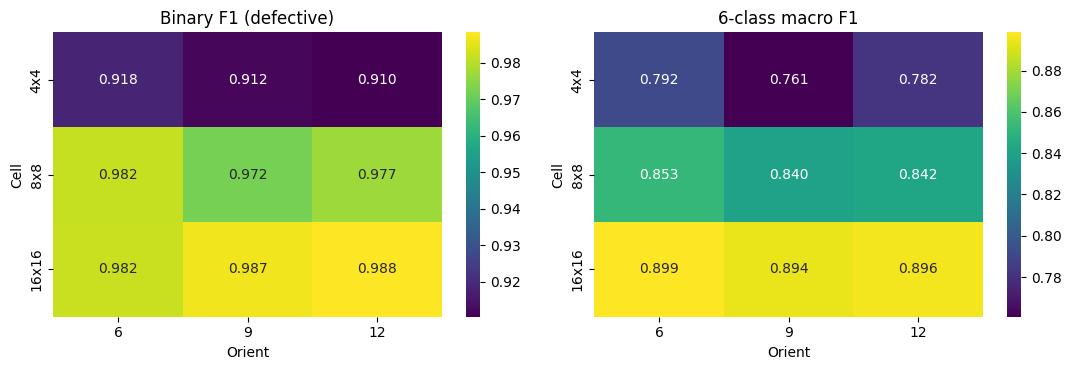

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, col, t in zip(ax, ["Bin_F1", "Multi_F1(macro)"], ["Binary F1 (defective)", "6-class macro F1"]):
    sns.heatmap(grid.pivot(index="Cell", columns="Orient", values=col).loc[[f"{c}x{c}" for c in CELL_SIZES]],
                annot=True, fmt=".3f", cmap="viridis", ax=a); a.set_title(t)
plt.tight_layout(); plt.show()

## 5. Experiment B: Classifier comparison at the best HOG setting

In [9]:
Xtr, Xte = extract(pre_tr, BEST_C, BEST_O), extract(pre_te, BEST_C, BEST_O)
models = {
    "SVM (RBF)":   lambda: new_svm(),
    "SVM (Linear)": lambda: SVC(kernel="linear", C=1, class_weight="balanced", random_state=SEED),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "kNN (k=5)":   lambda: KNeighborsClassifier(n_neighbors=5, metric="cosine", weights="distance"),
}
rows, preds = [], {}
for name, mk in models.items():
    t0 = time.time()
    pb = mk().fit(Xtr, y_tr_b).predict(Xte)
    pm = mk().fit(Xtr, y_tr_m).predict(Xte)
    preds[name] = (pb, pm)
    b, m = bin_metrics(y_te_b, pb), mc_metrics(y_te_m, pm)
    rows.append({"Classifier": name, "Bin_Acc": b["Accuracy"], "Bin_Prec": b["Precision"], "Bin_Rec": b["Recall"], "Bin_F1": b["F1"],
                 "Multi_Acc": m["Accuracy"], "Multi_Prec": m["Precision"], "Multi_Rec": m["Recall"], "Multi_F1": m["F1"],
                 "Time_s": time.time() - t0})
cmp_df = pd.DataFrame(rows); cmp_df.to_csv("results/classifier_comparison.csv", index=False)
box(f"EXPERIMENT B: CLASSIFIER COMPARISON (HOG cell {BEST_C}x{BEST_C}, {BEST_O} orient.)",
    cmp_df.round(4).to_string(index=False) + "\n\nBin_* = defective class (positive); Multi_* = macro-averaged over 6 classes")

+=======================================================================================================+
|                    EXPERIMENT B: CLASSIFIER COMPARISON (HOG cell 16x16, 12 orient.)                   |
+-------------------------------------------------------------------------------------------------------+
|    Classifier  Bin_Acc  Bin_Prec  Bin_Rec  Bin_F1  Multi_Acc  Multi_Prec  Multi_Rec  Multi_F1  Time_s |
|     SVM (RBF)   0.9806    0.9933   0.9833  0.9883     0.8972      0.8993     0.8972    0.8962  2.6212 |
|  SVM (Linear)   0.9417    0.9761   0.9533  0.9646     0.8361      0.8358     0.8361    0.8332  1.8490 |
| Random Forest   0.9500    0.9462   0.9967  0.9708     0.8667      0.8742     0.8667    0.8659 22.5184 |
|     kNN (k=5)   0.9250    0.9892   0.9200  0.9534     0.7667      0.8361     0.7667    0.7241  0.1386 |
|                                                                                                       |
| Bin_* = defective class (positive); Multi_* 

## 6. Confusion matrices and classification reports (best SVM)

+============================================================================+
|                     BINARY CLASSIFICATION REPORT (SVM)                     |
+----------------------------------------------------------------------------+
|                    precision    recall  f1-score   support                 |
|                                                                            |
| Non-Defective (0)     0.9206    0.9667    0.9431        60                 |
|     Defective (1)     0.9933    0.9833    0.9883       300                 |
|                                                                            |
|          accuracy                         0.9806       360                 |
|         macro avg     0.9570    0.9750    0.9657       360                 |
|      weighted avg     0.9812    0.9806    0.9807       360                 |
|                                                                            |
| Confusion matrix [rows=true, cols=pred]:          

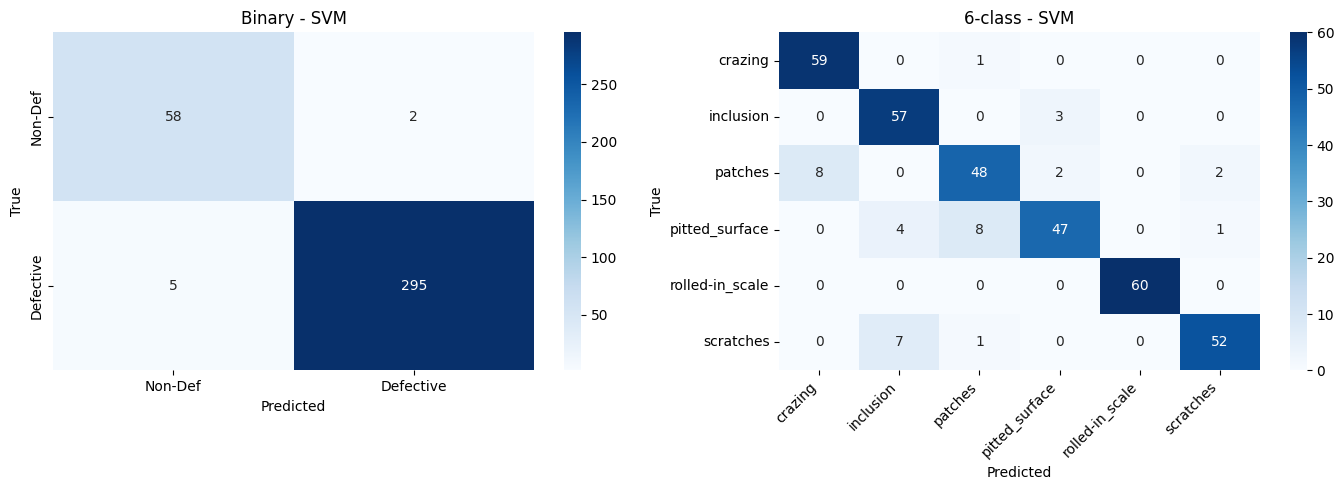

In [10]:
pb, pm = preds["SVM (RBF)"]
box("BINARY CLASSIFICATION REPORT (SVM)",
    classification_report(y_te_b, pb, target_names=["Non-Defective (0)", "Defective (1)"], digits=4) +
    "\nConfusion matrix [rows=true, cols=pred]:\n" + str(confusion_matrix(y_te_b, pb)))
box("6-CLASS CLASSIFICATION REPORT (SVM)", classification_report(y_te_m, pm, target_names=CLASSES, digits=4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_te_b, pb), annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Non-Def", "Defective"], yticklabels=["Non-Def", "Defective"]); ax[0].set_title("Binary - SVM")
sns.heatmap(confusion_matrix(y_te_m, pm), annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=CLASSES, yticklabels=CLASSES); ax[1].set_title("6-class - SVM")
for a in ax: a.set_xlabel("Predicted"); a.set_ylabel("True")
plt.setp(ax[1].get_xticklabels(), rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 7. Robustness analysis (brightness, noise, blur, rotation)

+=========================================================================================================+
|                           ROBUSTNESS RESULTS (SVM, change vs. clean baseline)                           |
+---------------------------------------------------------------------------------------------------------+
|           Condition  Bin_Acc  Bin_F1  Multi_Acc  Multi_F1  d_Bin_Acc  d_Bin_F1  d_Multi_Acc  d_Multi_F1 |
|    Clean (baseline)   0.9806  0.9883     0.8972    0.8962     0.0000    0.0000       0.0000      0.0000 |
|      Brightness +40   0.9722  0.9834     0.8194    0.8146    -0.0083   -0.0049      -0.0778     -0.0815 |
|      Brightness -40   0.9889  0.9933     0.9028    0.9014     0.0083    0.0051       0.0056      0.0052 |
| Gaussian noise s=10   0.7722  0.8429     0.5222    0.4487    -0.2083   -0.1454      -0.3750     -0.4475 |
| Gaussian noise s=25   0.3083  0.2906     0.1944    0.0886    -0.6722   -0.6977      -0.7028     -0.8076 |
|            Blur k=5   0.87

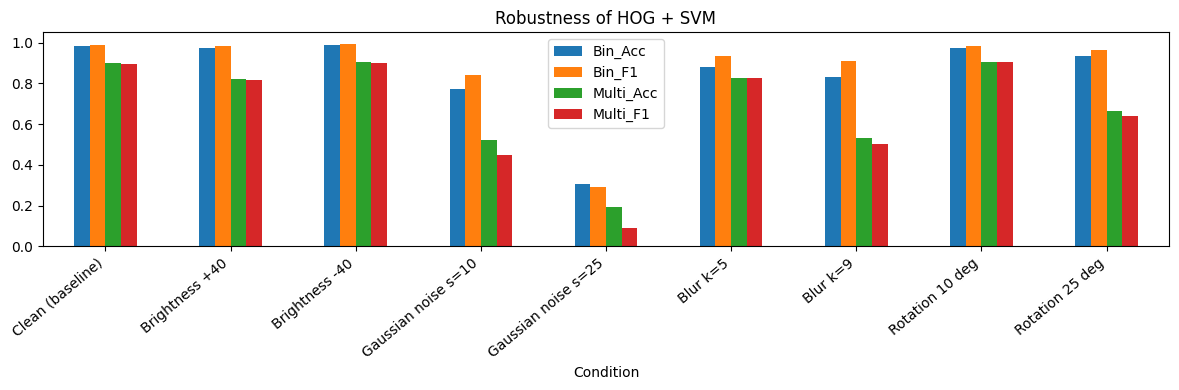

In [11]:
# Final models (probability=True gives the confidence used by the QC module)
svm_bin = new_svm(probability=True).fit(Xtr, y_tr_b)
svm_mc  = new_svm(probability=True).fit(Xtr, y_tr_m)

def brightness(img, beta):  return np.clip(img.astype(np.int16) + beta, 0, 255).astype(np.uint8)
def gnoise(img, sigma):
    rng = np.random.default_rng(SEED)
    return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)
def blur(img, k):           return cv2.GaussianBlur(img, (k, k), 0)
def rotate(img, deg):
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

conditions = [("Clean (baseline)", lambda x: x),
              ("Brightness +40", lambda x: brightness(x, 40)), ("Brightness -40", lambda x: brightness(x, -40)),
              ("Gaussian noise s=10", lambda x: gnoise(x, 10)), ("Gaussian noise s=25", lambda x: gnoise(x, 25)),
              ("Blur k=5", lambda x: blur(x, 5)), ("Blur k=9", lambda x: blur(x, 9)),
              ("Rotation 10 deg", lambda x: rotate(x, 10)), ("Rotation 25 deg", lambda x: rotate(x, 25))]

rob = []
for name, fn in conditions:
    Xp = extract([preprocess(fn(i)) for i in raw_te], BEST_C, BEST_O)
    b = bin_metrics(y_te_b, svm_bin.predict(Xp)); m = mc_metrics(y_te_m, svm_mc.predict(Xp))
    rob.append({"Condition": name, "Bin_Acc": b["Accuracy"], "Bin_F1": b["F1"], "Multi_Acc": m["Accuracy"], "Multi_F1": m["F1"]})
rob = pd.DataFrame(rob)
for col in ["Bin_Acc", "Bin_F1", "Multi_Acc", "Multi_F1"]:
    rob["d_" + col] = rob[col] - rob.loc[0, col]
rob.to_csv("results/robustness.csv", index=False)
box("ROBUSTNESS RESULTS (SVM, change vs. clean baseline)", rob.round(4).to_string(index=False) +
    "\n\nd_* columns = change relative to the clean baseline (negative = degradation)")

ax = rob.set_index("Condition")[["Bin_Acc", "Bin_F1", "Multi_Acc", "Multi_F1"]].plot.bar(figsize=(12, 4))
ax.set_ylim(0, 1.05); ax.set_title("Robustness of HOG + SVM"); plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

## 8. Industrial quality-control decision module

In [12]:
CONF_NAMES = {0: "NON-DEFECTIVE", 1: "DEFECTIVE"}

def inspect_product(img_or_path, verbose=True):
    """img_or_path: file path or grayscale/BGR numpy image. Returns dict and prints the inspection report."""
    img = cv2.imread(img_or_path, cv2.IMREAD_GRAYSCALE) if isinstance(img_or_path, str) else img_or_path
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    x = hog_feat(preprocess(img), BEST_C, BEST_O).reshape(1, -1)
    pb = svm_bin.predict_proba(x)[0]; label = int(np.argmax(pb)); conf = pb[label] * 100
    pm = svm_mc.predict_proba(x)[0]; dtype = CLASSES[int(np.argmax(pm))]
    action = "REJECT PRODUCT" if label == 1 else "ACCEPT PRODUCT"
    out = dict(prediction=CONF_NAMES[label], confidence=conf, action=action, defect_type=dtype)
    if verbose:
        box("PRODUCT INSPECTION RESULT",
            f"Prediction: {out['prediction']}\nConfidence: {conf:.1f}%\nAction: {action}\n"
            f"(Most likely surface type: {dtype})")
    return out

rng = np.random.default_rng(SEED)
for i in rng.choice(len(te_df), 4, replace=False):
    print(f"Test image: {os.path.basename(te_df.path[i])}   | true class: {te_df.cls[i]}")
    inspect_product(raw_te[i])

Test image: pitted_surface_212.jpg   | true class: pitted_surface
+============================================================================+
|                         PRODUCT INSPECTION RESULT                          |
+----------------------------------------------------------------------------+
| Prediction: DEFECTIVE                                                      |
| Confidence: 100.0%                                                         |
| Action: REJECT PRODUCT                                                     |
| (Most likely surface type: pitted_surface)                                 |
+============================================================================+

Test image: patches_149.jpg   | true class: patches
+============================================================================+
|                         PRODUCT INSPECTION RESULT                          |
+----------------------------------------------------------------------------+
| Prediction

## 9. Final summary

In [13]:
bc = cmp_df.set_index("Classifier")
box("FINAL SUMMARY",
    f"Best HOG setting       : cell {BEST_C}x{BEST_C}, {BEST_O} orientations (feature dim {Xtr.shape[1]})\n"
    f"SVM  binary  Acc / F1  : {bc.loc['SVM (RBF)','Bin_Acc']:.4f} / {bc.loc['SVM (RBF)','Bin_F1']:.4f}\n"
    f"SVM  6-class Acc / F1  : {bc.loc['SVM (RBF)','Multi_Acc']:.4f} / {bc.loc['SVM (RBF)','Multi_F1']:.4f}\n"
    f"RF   binary  Acc / F1  : {bc.loc['Random Forest','Bin_Acc']:.4f} / {bc.loc['Random Forest','Bin_F1']:.4f}\n"
    f"RF   6-class Acc / F1  : {bc.loc['Random Forest','Multi_Acc']:.4f} / {bc.loc['Random Forest','Multi_F1']:.4f}\n"
    f"Worst robustness drop  : {rob.iloc[1:].sort_values('d_Bin_F1').iloc[0].Condition} "
    f"(binary F1 {rob.iloc[1:].sort_values('d_Bin_F1').iloc[0].d_Bin_F1:+.4f})\n"
    f"Saved tables           : results/*.csv")

+============================================================================+
|                               FINAL SUMMARY                                |
+----------------------------------------------------------------------------+
| Best HOG setting       : cell 16x16, 12 orientations (feature dim 2352)    |
| SVM  binary  Acc / F1  : 0.9806 / 0.9883                                   |
| SVM  6-class Acc / F1  : 0.8972 / 0.8962                                   |
| RF   binary  Acc / F1  : 0.9500 / 0.9708                                   |
| RF   6-class Acc / F1  : 0.8667 / 0.8659                                   |
| Worst robustness drop  : Gaussian noise s=25 (binary F1 -0.6977)           |
| Saved tables           : results/*.csv                                     |
+============================================================================+

